Group 7 Final Project - DATASCI 151


Student ID Numbers: Alec Anghel (2697818), Stanley Yoo (2609643), Elsa Mathew-Lewis (2677374), Kimberly Yang (2670599)

# Formula One Data Analysis - What Makes A Winning Driver?

## Introduction
Formula One (F1) is a competitive motorsport, where both driver skill and car performance play an important role in determing race outcomes.  As a result, understanding what factors contribute to success in Formula One is an important and interesting data analysis problem as it can be used to better understand things such as: what drives a winning team, what makes a team better, and what can a team do to improve their outcomes. Through this project we aim to address some of these questions. 

One of these investigations is the relationship between qualifying performance and race results to determine whether starting position is a strong indicator of success. Through our exploration of driver demographics, race dates, and over 500,000 individual lap times, it became evident that Canadian and Italian drivers hold the fastest historical average pace. Additionally, our analysis shows a clear aging curve, showing drivers reach their peak speed between the ages of 26 and 32. We also explore whether drivers who perform well in qualifying sessions tend to achieve better final positions and earn more points in races. Using multiple datasets from F1 race records since 1950, we merge and analyze qualifying and race results to explore this relationship. Finally, we examine the data to determine if a driver's nationality correlates with a faster lap time and at what age F1 drivers typically reach their peak performances. Our findings suggest that there is a strong association between qualifying position and race outcomes, although other factors such as race conditions and strategy may also influence final performance. The project is structured by first introducing, describing, and cleaning the datasets, and then followed with the methods of analysis, and the results of our findings.

## Data Description
The data for this project came from a Formula 1 dataset found on Kaggle. Five main data sets were used for this analysis.

"drivers.csv": A data set with 854 containing observations of driver demographics. It cotains their names, dates of brith, and nationalities.

"lap_times.csv": A data set that contains 528,785 observations of individual lap times, race IDs, and milliseconds recorded.

"races.csv": A data set that contains 9,395 race dates. We will use this information alongside race ID to find the drivers exact age at the time of a race.

"qualifying.csv": A data set containing 25,660 observations about each driver's starting information for a race such as position and the driver identification

"results.csv": A data set containing 1,079 observations relating to final race outcomes, including finishing position and points earned.

In [1]:
# importing packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings("ignore")

In [2]:
# loading the datasets
drivers = pd.read_csv("f1_data/drivers.csv")
lap_times = pd.read_csv("f1_data/lap_times.csv")
qualifying = pd.read_csv("f1_data/qualifying.csv")
results = pd.read_csv("f1_data/results.csv")
races = pd.read_csv("f1_data/races.csv")

### Data Cleaning
Before we merge our data, the raw data needs to be cleaned for more accurate statiscal computing. In the drivers table, we replaced missing values ("\N") with "NaN" values, droped the unnecessary URL column, and converted the `dob` (Date of Birth) column into a usable datetime format. In the lap times table, we created a new column to convert the  "milliseconds" into  "seconds" to make our final plots and tables more understandable.

In [3]:
# Clean the drivers data set
# Replace the \N in the numbers with the NaN value
drivers = drivers.replace(r'\N', np.nan)

# Drop url column
drivers = drivers.drop(columns=['url'])

# Convert the date of birth to an actual date of birth format
drivers['dob'] = pd.to_datetime(drivers['dob'])

# Convert the number column into actual numeric values
drivers['number'] = pd.to_numeric(drivers['number'])

display(drivers)

,driverId,driverRef,number,code,forename,surname,dob,nationality
0,1,hamilton,44.0,HAM,Lewis,Hamilton,1985-01-07,British
1,2,heidfeld,NaN,HEI,Nick,Heidfeld,1977-05-10,German
2,3,rosberg,6.0,ROS,Nico,Rosberg,1985-06-27,German
3,4,alonso,14.0,ALO,Fernando,Alonso,1981-07-29,Spanish
4,5,kovalainen,NaN,KOV,Heikki,Kovalainen,1981-10-19,Finnish
...,...,...,...,...,...,...,...,...
849,851,aitken,89.0,AIT,Jack,Aitken,1995-09-23,British
850,852,tsunoda,22.0,TSU,Yuki,Tsunoda,2000-05-11,Japanese
851,853,mazepin,9.0,MAZ,Nikita,Mazepin,1999-03-02,Russian
852,854,mick_schumacher,47.0,MSC,Mick,Schumacher,1999-03-22,German


In [4]:
# Clean the lap_times data set
# Convert miliseconds into seconds
lap_times['seconds'] = lap_times['milliseconds'] / 1000
display(lap_times.round(2))

,raceId,driverId,lap,position,time,milliseconds,seconds
0,841,20,1,1,1:38.109,98109,98.11
1,841,20,2,1,1:33.006,93006,93.01
2,841,20,3,1,1:32.713,92713,92.71
3,841,20,4,1,1:32.803,92803,92.80
4,841,20,5,1,1:32.342,92342,92.34
...,...,...,...,...,...,...,...
528780,1086,842,65,13,1:25.989,85989,85.99
528781,1086,842,66,12,1:25.187,85187,85.19
528782,1086,842,67,12,1:47.355,107355,107.36
528783,1086,842,68,12,1:37.587,97587,97.59


### Merging Data
To analyze performance by driver attributes, we have to combine our tables. We performed an inner join on the "lap_times" and "drivers" datasets using the "driverId" column, since it appeared in both datasets. An inner join makes it so that our combined dataset only keeps rows where we have both a valid lap time and the corresponding driver's demographic details.

In [5]:
# Merge the data on the driverID column
# Inner join (only keep rows with both driver details and valid lap time)
f1_data = pd.merge(lap_times, drivers, on='driverId', how='inner')

display(f1_data.round(2))

,raceId,driverId,lap,position,time,milliseconds,seconds,driverRef,number,code,forename,surname,dob,nationality
0,841,20,1,1,1:38.109,98109,98.11,vettel,5.0,VET,Sebastian,Vettel,1987-07-03,German
1,841,20,2,1,1:33.006,93006,93.01,vettel,5.0,VET,Sebastian,Vettel,1987-07-03,German
2,841,20,3,1,1:32.713,92713,92.71,vettel,5.0,VET,Sebastian,Vettel,1987-07-03,German
3,841,20,4,1,1:32.803,92803,92.80,vettel,5.0,VET,Sebastian,Vettel,1987-07-03,German
4,841,20,5,1,1:32.342,92342,92.34,vettel,5.0,VET,Sebastian,Vettel,1987-07-03,German
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
528780,1086,842,65,13,1:25.989,85989,85.99,gasly,10.0,GAS,Pierre,Gasly,1996-02-07,French
528781,1086,842,66,12,1:25.187,85187,85.19,gasly,10.0,GAS,Pierre,Gasly,1996-02-07,French
528782,1086,842,67,12,1:47.355,107355,107.36,gasly,10.0,GAS,Pierre,Gasly,1996-02-07,French
528783,1086,842,68,12,1:37.587,97587,97.59,gasly,10.0,GAS,Pierre,Gasly,1996-02-07,French


To compare qualifying performance with race outcomes, the qualifying and results datasets were merged together. These two tables share the variables `raceId` and `driverId`, which uniquely identify a driver in a specific race. An inner merge was used so that only observations appearing in both datasets were kept. This allows each row in the merged table to represent one driver in one race, with both that driver’s qualifying position and final race result included in the same dataset. After merging, the relevant columns were renamed for clarity so that qualifying position and race finishing position could be distinguished more easily in the analysis.

After merging the datasets, several data cleaning steps were performed to ensure the dataset was suitable for analysis. First, only the relevant columns needed for this study were retained, including qualifying position, race finishing position, and points. Rows containing missing values were removed to avoid inaccuracies in the analysis. Additionally, the dataset was checked for consistency in data types, and the columns were kept in numerical form to allow for proper comparisons and calculations. These cleaning steps ensure that the dataset is accurate and ready for analyzing the relationship between qualifying performance and race outcomes.

In [6]:
# merging qualifying and results data sets

qualifying_small = qualifying[["raceId", "driverId", "position"]]
results_small = results[["raceId", "driverId", "positionOrder", "points"]]

merged = pd.merge(qualifying_small, results_small, on=["raceId", "driverId"], how="inner")

merged = merged.rename(columns={
    "position": "qualifying_position",
    "positionOrder": "race_position"
})

merged.head()

# Drop missing values
merged = merged.dropna()

# Ensure numeric data types
merged["qualifying_position"] = pd.to_numeric(merged["qualifying_position"])
merged["race_position"] = pd.to_numeric(merged["race_position"])
merged["points"] = pd.to_numeric(merged["points"])

# Reset index after cleaning
merged = merged.reset_index(drop=True)

# Check cleaned data
merged.head()

,raceId,driverId,qualifying_position,race_position,points
0,18,1,1,1,10.0
1,18,9,2,9,0.0
2,18,5,3,5,4.0
3,18,13,4,13,0.0
4,18,2,5,2,8.0


### Main Columns and Descriptive Statistics
Our main columns of interest for the analysis are "nationality", "seconds", and later, the driver's calculated "age". Below is a table of descriptive statistics for our seconds variable. The mean tells us that one lap takes 95.68 seconds to complete, on average. The fastest lap time recorded in the data set is 55.4 seconds and the longest one is 7,507.55 seconds.

The main columns used in our secondary analysis are qualifying_position, race_position, and points. The qualifying_position column represents the position a driver starts in after the qualifying session, while the race_position column represents the driver’s final finishing position in the race. The points column indicates how many championship points the driver earned in that race. These columns are important because they allow us to directly compare starting performance with race outcomes. By examining these variables, we can analyze whether drivers who start in better positions tend to finish in better positions and earn more points.

In [7]:
# Descriptive statistics for numerical column, rounded to 2 decimal places
descriptive_stats = f1_data[['seconds']].describe().round(2)
display(descriptive_stats.iloc[1:,:])

,seconds
mean,95.68
std,75.34
min,55.40
25%,82.06
50%,90.67
75%,102.21
max,7507.55


In [8]:
# Summary statisitcs of relevant columns, rounded to two decimal places
display(merged[["qualifying_position", "race_position", "points"]].describe().round(2))

,qualifying_position,race_position,points
count,9395.00,9395.00,9395.00
mean,11.28,11.30,3.39
std,6.31,6.32,5.87
min,1.00,1.00,0.00
25%,6.00,6.00,0.00
50%,11.00,11.00,0.00
75%,17.00,17.00,5.00
max,28.00,28.00,50.00


## Results

#### Driver Pace by Nationality
To learn if drivers from certain countries are actually faster, we should group lap times by driver nationality. To make sure our analysis is make sense, we first filter out laps that don't make sense, or are affected by external factors (such as pit stops, safety cars, or crashes) by capping normal laps at 120 seconds. We should also filter the final table to only include countries with over 10,000 recorded laps to make a fair sample size. We then use a bar plot to visualize the average lap time for each country side-by-side, to more easily draw comparisons.

In [9]:
# Filter out abnormally slow laps (potentially due to external factors)
clean_laps = f1_data[f1_data['seconds'] < 120]

# Group by nationality for mean lap time and total lap count
nation_table = clean_laps.groupby('nationality')['seconds'].agg(['mean', 'count'])

# Only include countries that have more than 10000 recorded laps
nation_table = nation_table[nation_table['count'] > 10000]

nation_table = nation_table.sort_values(by='mean')
display(nation_table.round(2))

,mean,count
nationality,,
Canadian,89.09,16461
Italian,89.68,33030
Dutch,90.52,14836
British,90.76,71982
Finnish,90.97,42401
Brazilian,91.14,43973
German,91.21,83774
Spanish,91.48,33931
Australian,91.69,21914


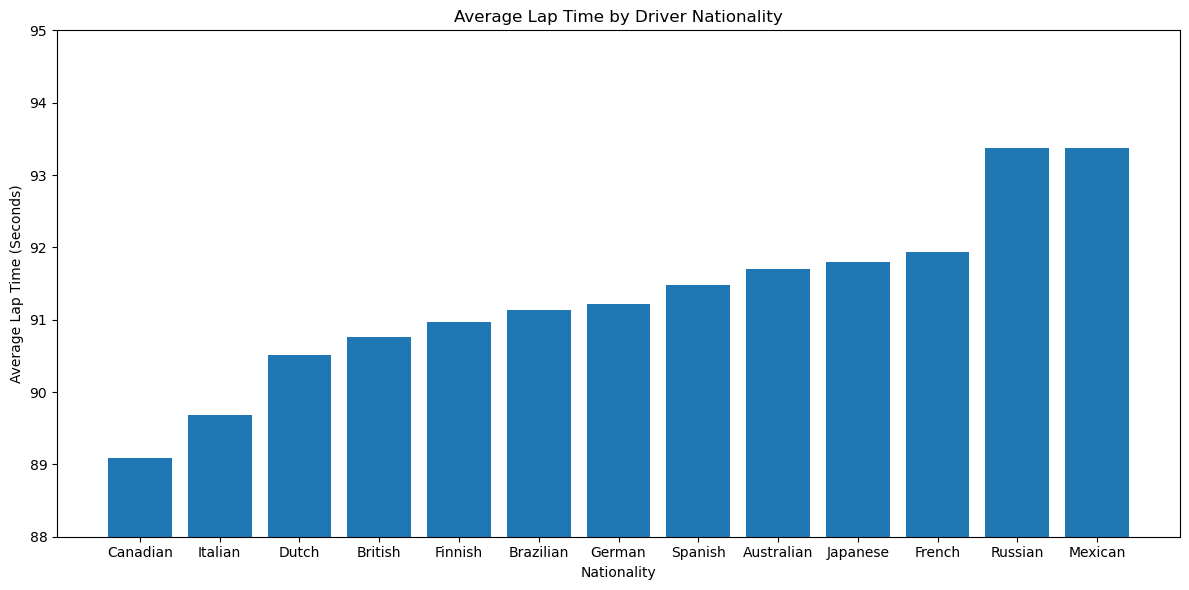

In [10]:
plt.figure(figsize=(12, 6))
plt.bar(nation_table.index, nation_table['mean'])
plt.title('Average Lap Time by Driver Nationality')
plt.xlabel('Nationality')
plt.ylabel('Average Lap Time (Seconds)')
plt.ylim(88, 95)
plt.tight_layout()

plt.show()

#### Driver Age vs. Performance
To look at how the age of a  Formula 1 driver affects their performance, we need to calculate their exact age on the day they drove the lap. To do this, we need to merge our current dataset with the "races.csv" file using an inner join on "raceId" to find the date of the event. By subtracting the driver's date of birth from the race date, we can group normal racing laps by age and see the actual performance trend.

In [11]:
# Only keep raceId and date columns
races_clean = races[["raceId","date"]]

# Convert date into datetime format
races_clean['date'] = pd.to_datetime(races_clean['date'])

# Merge
f1_data = pd.merge(f1_data, races_clean, on='raceId', how='inner')

# Subtract date of event from driver dob, then convert it to years
# Divide by 365.25 (because using leap years that is the average amount of days in a year)
f1_data['driver_age'] = (f1_data['date'] - f1_data['dob']).dt.days / 365.25

f1_data['age_years'] = np.floor(f1_data['driver_age'])

display(f1_data.round(2))

,raceId,driverId,lap,position,time,milliseconds,seconds,driverRef,number,code,forename,surname,dob,nationality,date,driver_age,age_years
0,841,20,1,1,1:38.109,98109,98.11,vettel,5.0,VET,Sebastian,Vettel,1987-07-03,German,2011-03-27,23.73,23.0
1,841,20,2,1,1:33.006,93006,93.01,vettel,5.0,VET,Sebastian,Vettel,1987-07-03,German,2011-03-27,23.73,23.0
2,841,20,3,1,1:32.713,92713,92.71,vettel,5.0,VET,Sebastian,Vettel,1987-07-03,German,2011-03-27,23.73,23.0
3,841,20,4,1,1:32.803,92803,92.80,vettel,5.0,VET,Sebastian,Vettel,1987-07-03,German,2011-03-27,23.73,23.0
4,841,20,5,1,1:32.342,92342,92.34,vettel,5.0,VET,Sebastian,Vettel,1987-07-03,German,2011-03-27,23.73,23.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
528780,1086,842,65,13,1:25.989,85989,85.99,gasly,10.0,GAS,Pierre,Gasly,1996-02-07,French,2022-07-31,26.48,26.0
528781,1086,842,66,12,1:25.187,85187,85.19,gasly,10.0,GAS,Pierre,Gasly,1996-02-07,French,2022-07-31,26.48,26.0
528782,1086,842,67,12,1:47.355,107355,107.36,gasly,10.0,GAS,Pierre,Gasly,1996-02-07,French,2022-07-31,26.48,26.0
528783,1086,842,68,12,1:37.587,97587,97.59,gasly,10.0,GAS,Pierre,Gasly,1996-02-07,French,2022-07-31,26.48,26.0


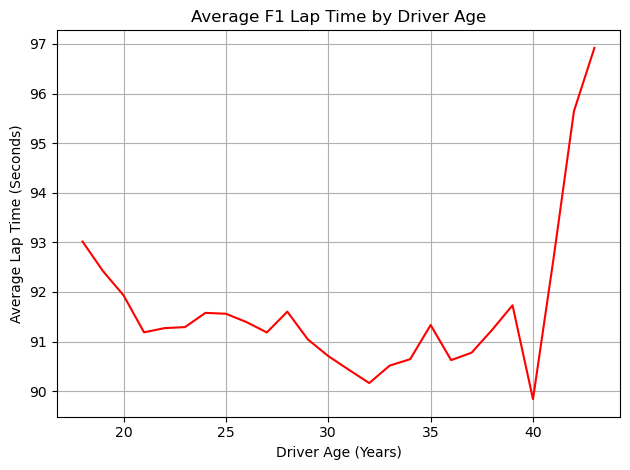

In [12]:
# Filter for normal laps
clean_laps = f1_data[f1_data['seconds'] < 120]

# Filter for only normal racing years, keep ages 18 to 45 only
age_filtered = clean_laps[(clean_laps['age_years'] >= 18) & (clean_laps['age_years'] <= 45)]

# Group by age to find average lap time for each age group
age_table = age_filtered.groupby('age_years')['seconds'].mean()

plt.plot(age_table.index, age_table.values, color = "red")
plt.title('Average F1 Lap Time by Driver Age')
plt.xlabel('Driver Age (Years)')
plt.ylabel('Average Lap Time (Seconds)') 
plt.tight_layout()
plt.grid(True)
plt.show()

#### Qualifying Position vs. Race Position

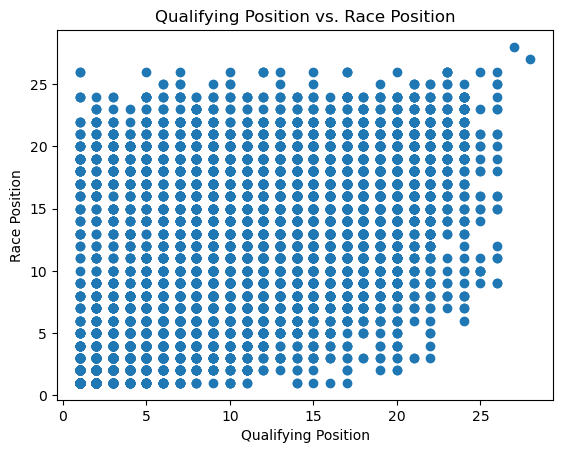

In [13]:
plt.scatter(merged["qualifying_position"], merged["race_position"])
plt.xlabel("Qualifying Position")
plt.ylabel("Race Position")
plt.title("Qualifying Position vs. Race Position")
plt.show()

We chose to visualize qualifying position vs. final race position via a scatterplot as we hypothesize that there will be a positive correlation between the two. The scatter plot confirms this as there appears to be a positive relationship, where drivers who start in better positions (lower qualifying numbers) tend to finish in better positions as well. While there is some variability, the general trend suggests that qualifying performance is an important factor in determining race outcomes.

In [14]:
merged[["qualifying_position", "race_position"]].corr().round(2)

,qualifying_position,race_position
qualifying_position,1.00,0.57
race_position,0.57,1.00


The correlation coefficient between qualifying position and race position is positive, indicating that there is a relationship between the two variables. This suggests that drivers who qualify in better positions are more likely to finish in better positions in the race. However, the correlation is not perfect, meaning that other factors such as race strategy, pit stops, and unexpected events may also influence the final results.

In [15]:
avg_finish = merged.groupby("qualifying_position")["race_position"].mean().round(2)

avg_finish.head()

qualifying_position
1    4.32
2    5.37
3    6.23
4    6.65
5    8.13
Name: race_position, dtype: float64

When grouping by qualifying position, we observe that drivers starting in higher grid positions tend to have better average finishing positions. This further supports the idea that qualifying performance plays a role in determing race outcomes.

### Discussion
In this project, we successfully combined and manipulated multiple datasets to find historical trends in F1 racing. We found that Canadian and Italian drivers hold the fastest average lap times in the sport's history, both averaging under 90 seconds for a normal racing lap. However, it is also important to note the impact of sample size: German and British drivers have recorded a lot more laps than any other nationality (over 70,000 laps each) and they still have a very competitive average of around 91 seconds. Furthermore, our analysis also gave important insights in regards to the correlation between a driver's age and their performance. By visualizing average lap times across the typical duration of a driver's career, we can see that drivers usually perform their best between the ages of 26 and 32. This represents a peak performance range where the benefits of being young intersect with the experience of a driver. Drivers younger and older than this age range both display slightly slower average paces in comparison.

We also examined the relationship between qualifying position and race performance. The results show a clear positive relationship between qualifying position and final race position, indicating that drivers who start in better positions are more likely to finish in better positions. This trend was supported both visually through the scatter plot and numerically through the correlation analysis, suggesting that qualifying performance is an important factor in race outcomes. However, this relationship is not perfect, which indicates that other factors also influence race results. Elements such as race strategy, pit stops, mechanical issues, and driver decisions during the race can all impact final performance. Overall, this analysis highlights the importance of qualifying position while also demonstrating that success in F1 is influenced by multiple factors beyond just starting position.